In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import FastICA
from utils import load_images
import joblib 
import pathlib
from pathlib import Path

from numpy.random import default_rng

rng = default_rng(seed=42)

In [2]:
basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40/layer2_models")

model_list = []
for entry in basepath.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        model_list.append(model)

print(model_list)

images = load_images(crop_size=36)
print("loaded images shape", images.shape)

n_patch_components = model.components_.shape[0]
print("n_components", n_patch_components)
n_patch_pixels = model.components_.shape[1]
print("n_patch_pixels", n_patch_pixels)

[FastICA(n_components=40, random_state=752767290, whiten='unit-variance'), FastICA(n_components=40, random_state=3653403230, whiten='unit-variance'), FastICA(n_components=40, random_state=70985653, whiten='unit-variance'), FastICA(n_components=40, random_state=323153948, whiten='unit-variance'), FastICA(n_components=40, random_state=1322117303, whiten='unit-variance'), FastICA(n_components=40, random_state=2195314464, whiten='unit-variance'), FastICA(n_components=40, random_state=2735729614, whiten='unit-variance'), FastICA(n_components=40, random_state=175979944, whiten='unit-variance'), FastICA(n_components=40, random_state=1158725111, whiten='unit-variance')]
loaded images shape (20000, 36, 36)
n_components 40
n_patch_pixels 144


In [3]:
A_plus = []
for model in model_list:
    A_plus.append(model.mixing_)
A_plus = np.array(A_plus)
print("A_plus shape", A_plus.shape)

A_plus shape (9, 144, 40)


In [4]:
image_dim = images.shape[-1] * images.shape[-2]

In [5]:
A_star = np.zeros((n_patch_pixels * 9, n_patch_components * 9))
for idx, A in enumerate(A_plus):
    A_star[
        idx * n_patch_pixels: (idx + 1) * n_patch_pixels,
        idx * n_patch_components: (idx + 1) * n_patch_components,
    ] = A
print("A_star shape", A_star.shape)

A_star shape (1296, 360)


In [6]:
# np.save(basepath / "layer1_mappings.npy", A_star)

In [7]:
random_latent_vec = rng.random(360).reshape(1, -1)

In [8]:
random_latent_vec.shape

(1, 360)

In [9]:
random_latent_vec_cut = random_latent_vec.reshape(1, 9, 40)

In [14]:
new_img = (A_star @ random_latent_vec.T)

In [15]:
new_img.shape, new_img.squeeze(1).shape

((1296, 1), (1296,))

In [16]:
new_img = new_img.squeeze(1)
print(new_img.shape)

(1296,)


In [32]:
images_produced_new = []
proper_images = []
for vec, model in zip(random_latent_vec_cut[0, :, :], model_list):
    A_model = model.mixing_
    img = A_model @ vec
    proper_img = model.inverse_transform(vec.reshape(1, -1))
    proper_images.append(proper_img)
    images_produced_new.append(img)
images_produced_new = np.array(images_produced_new)
proper_images = np.array(proper_images)

In [33]:
images_produced_new.reshape(1296).shape
images_produced_new = images_produced_new.reshape(1296)
proper_images = proper_images.reshape(1296)

In [19]:
np.all(images_produced_new == new_img)

False

In [20]:
new_img

array([ 8.97102503, 14.62422121, 17.29500594, ..., 17.76690363,
       27.29892068, 34.16776556])

In [21]:
images_produced_new

array([ 8.97102503, 14.62422121, 17.29500594, ..., 17.76690363,
       27.29892068, 34.16776556])

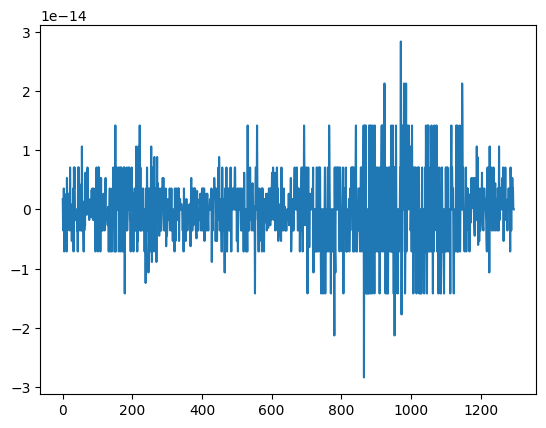

In [22]:
plt.plot(images_produced_new - new_img)

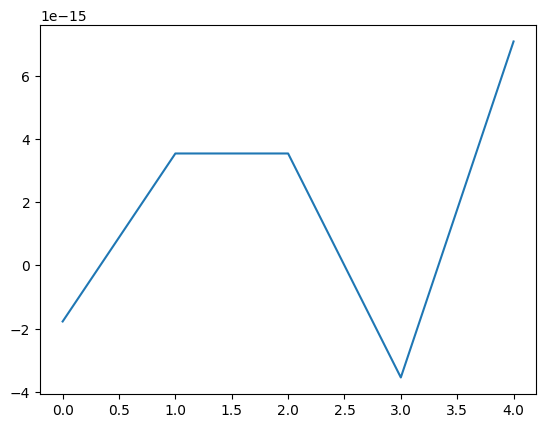

In [23]:
plt.plot((new_img - images_produced_new)[:5])